# Notebook 03 — Feature Engineering
### Credit Risk — Probability of Default (PD) Scorecard | Stage 4

---

## What this notebook does

The SQL pipeline (notebook 02) produced 81 columns of cleaned raw values and
all-time aggregates. Raw values are rarely the best predictors — **relationships**
between values usually are: a 500k loan means different things to someone
earning 100k versus 1M. This notebook builds **17 engineered features in four
batches**, testing every single one against `TARGET` before keeping it:

| Batch | Theme | Features |
|---|---|---|
| 1 | Core financial ratios | `CREDIT_ANNUITY_RATIO`, `CREDIT_GOODS_PRICE_RATIO`, `CREDIT_DOWNPAYMENT`, `AGE_INT`, `DEBT_CREDIT_RATIO` |
| 2 | EXT_SOURCE combinations + payment capacity | `EXT_SOURCE_MEAN/SUM/STD`, `ANNUITY_TO_AVG_INSTALMENT` |
| 3 | Recency (time-window) features | `RECENT_BUREAU_LOAN_COUNT`, `RECENT_BUREAU_MAX_OVERDUE`, `HAS_RECENT_OVERDUE`, `HAS_RECENT_LATE_PAYMENT`, `RECENT_AVG_UTILIZATION` |
| 4 | Standard community ratios | `CREDIT_INCOME_PERCENT`, `ANNUITY_INCOME_PERCENT`, `CREDIT_TERM` |

Batch 3 tests a specific hypothesis from the published 2018 competition
winner's writeup — *recent behaviour predicts better than all-time behaviour* —
and refines it against this project's own data (confirmed for discrete events,
**refuted** for continuous states).

**Inputs:** `model_ready_dataset.csv` (307,511 × 81) + three cleaned child
tables for the time-window features
**Output:** `model_ready_features.csv` (307,511 × 98)

> Run from the project root, top to bottom (`Kernel → Restart & Run All`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH = "data/home_credit_data/"
FIG_PATH  = "outputs/figures/"
os.makedirs(FIG_PATH, exist_ok=True)

C_RED, C_BLUE, C_GREEN, C_GREY = '#e34948', '#378ADD', '#1D9E75', '#888780'

df = pd.read_csv(DATA_PATH + "model_ready_dataset.csv")
print(f"Input shape: {df.shape}")
assert df.shape == (307511, 81), "Unexpected input - re-run notebook 02 first"


Input shape: (307511, 81)


# Batch 1 — Core financial ratios

Five features combining application amounts and the SQL-aggregated bureau
totals. One construction rule used throughout this notebook: **check the
denominator before dividing** — a zero denominator produces infinity, and
neither 0 nor infinity is a meaningful value for an undefined ratio, so
undefined cases become `NaN`.

In [2]:
# How common is the zero-denominator problem for the bureau ratio?
print(f"Customers with BUREAU_TOTAL_CREDIT_SUM = 0 : {(df['BUREAU_TOTAL_CREDIT_SUM'] == 0).sum():,}")
print(f"  ...of which have NO bureau history at all : "
      f"{((df['BUREAU_TOTAL_CREDIT_SUM'] == 0) & (df['BUREAU_LOAN_COUNT'] == 0)).sum():,}")
print(f"  ...of which have loans but 0 reported sum : "
      f"{((df['BUREAU_TOTAL_CREDIT_SUM'] == 0) & (df['BUREAU_LOAN_COUNT'] > 0)).sum():,}")

Customers with BUREAU_TOTAL_CREDIT_SUM = 0 : 45,103
  ...of which have NO bureau history at all : 44,020
  ...of which have loans but 0 reported sum : 1,083


**Finding.** ~45k customers have a zero credit sum — mostly the no-bureau-history
group. A naive division would create infinities wherever debt > 0 with sum = 0.
`DEBT_CREDIT_RATIO` is therefore built with an explicit guard from the start.

In [3]:
# 1. How large is the loan relative to the yearly payment? (loan duration proxy)
df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']

# 2. Loan amount vs price of the goods being financed (>1 = borrowing beyond the purchase)
df['CREDIT_GOODS_PRICE_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

# 3. Downpayment in currency terms (goods price minus loan)
df['CREDIT_DOWNPAYMENT'] = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']

# 4. Age in years (DAYS_BIRTH is negative days)
df['AGE_INT'] = (df['DAYS_BIRTH'] / -365).astype(int)

# 5. Bureau debt burden: share of external credit still owed (guarded division)
df['DEBT_CREDIT_RATIO'] = np.where(
    df['BUREAU_TOTAL_CREDIT_SUM'] > 0,
    df['BUREAU_TOTAL_DEBT'] / df['BUREAU_TOTAL_CREDIT_SUM'],
    np.nan
)

batch1 = ['CREDIT_ANNUITY_RATIO', 'CREDIT_GOODS_PRICE_RATIO',
          'CREDIT_DOWNPAYMENT', 'AGE_INT', 'DEBT_CREDIT_RATIO']

print(df[batch1].describe())
print(f"\nInfinite values across batch 1: "
      f"{sum(np.isinf(df[c]).sum() for c in batch1)}")

       CREDIT_ANNUITY_RATIO  CREDIT_GOODS_PRICE_RATIO  CREDIT_DOWNPAYMENT  \
count             307499.00                 307233.00           307233.00   
mean                  21.61                      1.12           -60918.80   
std                    7.82                      0.12            70495.12   
min                    8.04                      0.15          -540000.00   
25%                   15.61                      1.00           -99972.00   
50%                   20.00                      1.12           -39204.00   
75%                   27.10                      1.20                0.00   
max                   45.31                      6.00           765000.00   

        AGE_INT  DEBT_CREDIT_RATIO  
count 307511.00          262408.00  
mean      43.44               0.28  
std       11.95               0.28  
min       20.00               0.00  
25%       34.00               0.00  
50%       43.00               0.21  
75%       53.00               0.47  
max       

AGE_INT                    -0.08
CREDIT_DOWNPAYMENT         -0.03
CREDIT_ANNUITY_RATIO       -0.03
CREDIT_GOODS_PRICE_RATIO    0.07
DEBT_CREDIT_RATIO           0.10
Name: TARGET, dtype: float64


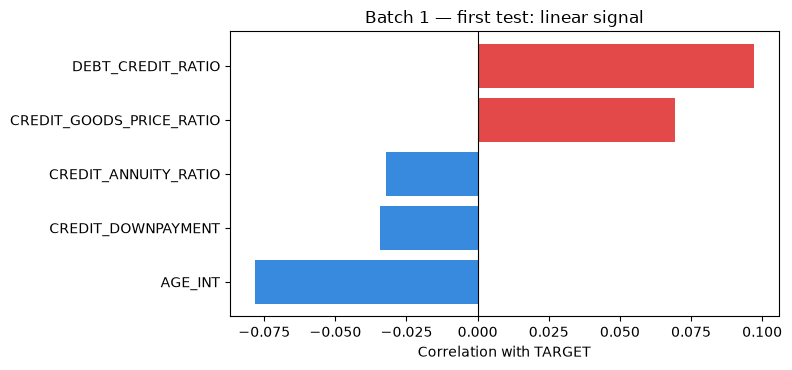

In [4]:
correlations = df[batch1 + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()
print(correlations)

fig, ax = plt.subplots(figsize=(8, 3.8))
colors = [C_BLUE if v < 0 else C_RED for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET')
ax.set_title('Batch 1 — first test: linear signal')
plt.tight_layout()
plt.savefig(FIG_PATH + "03_batch1_correlations.png", dpi=150, bbox_inches='tight')
plt.show()

**First read.** `DEBT_CREDIT_RATIO` (+0.097) and `CREDIT_GOODS_PRICE_RATIO`
(+0.069) lead the batch; `AGE_INT` (−0.078) confirms the age pattern from EDA.
`CREDIT_DOWNPAYMENT` and `CREDIT_ANNUITY_RATIO` look weak linearly — but
correlation misses non-linear patterns, so both get a bucket test before any
verdict.

BUCKET
(-0.001, 0.107]    5.70
(0.107, 0.31]      6.69
(0.31, 0.533]      8.30
(0.533, 7.789]    12.26
Name: TARGET, dtype: float64


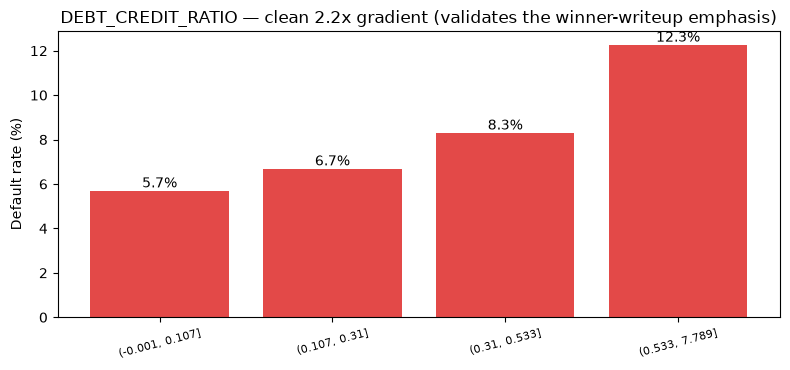

In [5]:
# Bucket test for the leading feature — is the gradient clean?
tmp = df.dropna(subset=['DEBT_CREDIT_RATIO']).copy()
tmp['BUCKET'] = pd.qcut(tmp['DEBT_CREDIT_RATIO'], q=5, duplicates='drop')

dcr = tmp.groupby('BUCKET', observed=True)['TARGET'].mean() * 100
print(dcr)

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(range(len(dcr)), dcr.values, color=C_RED)
ax.set_xticks(range(len(dcr)))
ax.set_xticklabels([str(b) for b in dcr.index], rotation=15, fontsize=8)
for b, v in zip(bars, dcr.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.15, f"{v:.1f}%", ha='center', fontsize=10)
ax.set_ylabel('Default rate (%)')
ax.set_title('DEBT_CREDIT_RATIO — clean 2.2x gradient (validates the winner-writeup emphasis)')
plt.tight_layout()
plt.savefig(FIG_PATH + "03_debt_credit_gradient.png", dpi=150, bbox_inches='tight')
plt.show()

**Verdict — KEEP.** 5.7% → 12.3% default (2.2x) across debt-burden buckets.
Only 4 distinct buckets form instead of 5 because 77k+ customers sit at exactly
0 (no outstanding debt) — expected, consistent with the denominator
investigation above. This validates the winner's emphasis on this exact
feature *with our own data*.

CREDIT_ANNUITY_RATIO buckets:
CAR_BUCKET
(8.036000000000001, 14.63]   8.07
(14.63, 19.536]              9.95
(19.536, 22.01]              9.68
(22.01, 30.143]              6.18
(30.143, 45.305]             6.49
Name: TARGET, dtype: float64

CREDIT_DOWNPAYMENT buckets:
CDP_BUCKET
(-540000.001, -117612.0]   9.16
(-117612.0, -60408.0]      9.79
(-60408.0, -17820.0]       8.24
(-17820.0, 0.0]            6.58
(0.0, 765000.0]            5.00
Name: TARGET, dtype: float64


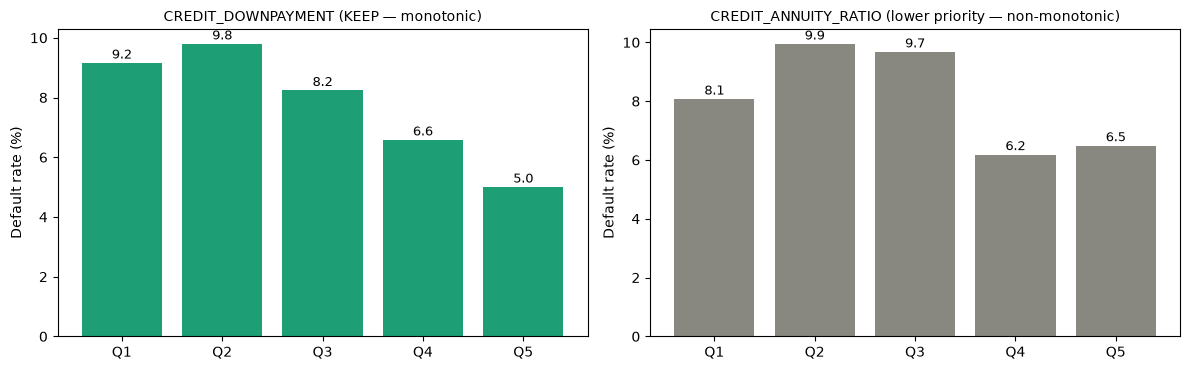

In [6]:
# Bucket test for the two weak-correlation features
tmp = df[['CREDIT_ANNUITY_RATIO', 'CREDIT_DOWNPAYMENT', 'TARGET']].copy()
tmp['CAR_BUCKET'] = pd.qcut(tmp['CREDIT_ANNUITY_RATIO'], q=5, duplicates='drop')
tmp['CDP_BUCKET'] = pd.qcut(tmp['CREDIT_DOWNPAYMENT'], q=5, duplicates='drop')

car = tmp.groupby('CAR_BUCKET', observed=True)['TARGET'].mean() * 100
cdp = tmp.groupby('CDP_BUCKET', observed=True)['TARGET'].mean() * 100
print("CREDIT_ANNUITY_RATIO buckets:"); print(car)
print("\nCREDIT_DOWNPAYMENT buckets:"); print(cdp)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, series, name, color in [(axes[0], cdp, 'CREDIT_DOWNPAYMENT (KEEP — monotonic)', C_GREEN),
                                (axes[1], car, 'CREDIT_ANNUITY_RATIO (lower priority — non-monotonic)', C_GREY)]:
    bars = ax.bar(range(len(series)), series.values, color=color)
    for b, v in zip(bars, series.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.15, f"{v:.1f}", ha='center', fontsize=9)
    ax.set_xticks(range(len(series)))
    ax.set_xticklabels([f"Q{i+1}" for i in range(len(series))])
    ax.set_ylabel('Default rate (%)')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_PATH + "03_batch1_bucket_verdicts.png", dpi=150, bbox_inches='tight')
plt.show()

**Verdicts.** `CREDIT_DOWNPAYMENT`: clean monotonic ~2x gradient (5.0% → 9.8%)
with obvious business logic (bigger downpayment = financial stability) —
**KEEP** despite the weak linear correlation; the bucket test caught what
correlation missed. `CREDIT_ANNUITY_RATIO`: real spread but rises-then-falls
with no clean interpretation — **LOWER PRIORITY**, carried into Stage 5 for
IV/SHAP to judge rather than dropped by hand. (Diagnostic buckets were built
on a temporary copy — `df` stays clean.)

# Batch 2 — EXT_SOURCE combinations & payment capacity

EDA showed the three external scores are individually the strongest raw
columns (corr −0.16 to −0.18). Hypothesis: they are three noisy estimates of
the same underlying creditworthiness, so **averaging should cancel noise** —
the same principle that makes ensembles work.

In [7]:
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df['EXT_SOURCE_SUM']  = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].sum(axis=1)
df['EXT_SOURCE_STD']  = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

# Payment capacity: proposed annuity vs the customer's historical average instalment.
# Guard BOTH failure modes: no payment history (zero records) AND near-zero
# average instalment (which produced a 115,238 ratio in early testing).
avg_instalment = df['TOTAL_INSTALMENT_DUE'] / df['NUM_PAYMENT_RECORDS'].replace(0, np.nan)
df['ANNUITY_TO_AVG_INSTALMENT'] = np.where(
    (df['NUM_PAYMENT_RECORDS'] > 0) & (avg_instalment > 0),
    df['AMT_ANNUITY'] / avg_instalment,
    np.nan
)

batch2 = ['EXT_SOURCE_MEAN', 'EXT_SOURCE_SUM', 'EXT_SOURCE_STD', 'ANNUITY_TO_AVG_INSTALMENT']
print(df[batch2].describe())

       EXT_SOURCE_MEAN  EXT_SOURCE_SUM  EXT_SOURCE_STD  \
count        307339.00       307511.00       270602.00   
mean              0.51            1.14            0.15   
std               0.15            0.47            0.10   
min               0.00            0.00            0.00   
25%               0.41            0.80            0.07   
50%               0.52            1.14            0.14   
75%               0.62            1.44            0.21   
max               0.88            2.56            0.65   

       ANNUITY_TO_AVG_INSTALMENT  
count                  291628.00  
mean                        3.11  
std                       216.63  
min                         0.01  
25%                         1.03  
50%                         1.82  
75%                         3.17  
max                    115238.10  


In [8]:
# Outlier audit on the new ratio — same gap-ratio test used in EDA
col = 'ANNUITY_TO_AVG_INSTALMENT'
print(f"99th pct   : {df[col].quantile(0.99):.2f}")
print(f"99.9th pct : {df[col].quantile(0.999):.2f}")
print(f"max        : {df[col].max():,.2f}")
print(f"gap ratio (max / 99.9th): {df[col].max() / df[col].quantile(0.999):,.0f}x")

99th pct   : 12.23
99.9th pct : 28.10
max        : 115,238.10
gap ratio (max / 99.9th): 4,102x


**The most extreme outlier ratio in the project.** Max sits thousands of times
beyond the 99.9th percentile — caused by a handful of near-zero (but not
exactly zero) average instalments inflating the division. Same treatment as
EDA's income outlier: **winsorise at the 99th percentile**.

In [9]:
cap_value = df['ANNUITY_TO_AVG_INSTALMENT'].quantile(0.99)
df['ANNUITY_TO_AVG_INSTALMENT'] = df['ANNUITY_TO_AVG_INSTALMENT'].clip(upper=cap_value)
print(f"Capped at {cap_value:.2f} — new max: {df['ANNUITY_TO_AVG_INSTALMENT'].max():.2f}")

Capped at 12.23 — new max: 12.23


In [10]:
correlations = df[batch2 + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()
print(correlations)

EXT_SOURCE_MEAN             -0.22
EXT_SOURCE_SUM              -0.17
ANNUITY_TO_AVG_INSTALMENT    0.03
EXT_SOURCE_STD               0.05
Name: TARGET, dtype: float64


**Key finding — `EXT_SOURCE_MEAN` is the strongest feature found anywhere in
this project.** Correlation −0.222 beats every individual score (−0.16 to
−0.18) and every other feature including `AVG_UTILIZATION`. Averaging worked
exactly as hypothesised. `EXT_SOURCE_SUM` (−0.173) carries near-duplicate
information (Stage 5's correlation filter will arbitrate). `EXT_SOURCE_STD` —
the *disagreement* between the three sources — shows a weak positive
correlation: profiles the bureaus can't agree on are slightly riskier.

QUINTILE
Q1 (lowest)    18.72
Q2              9.31
Q3              5.91
Q4              3.95
Q5 (highest)    2.48
Name: TARGET, dtype: float64


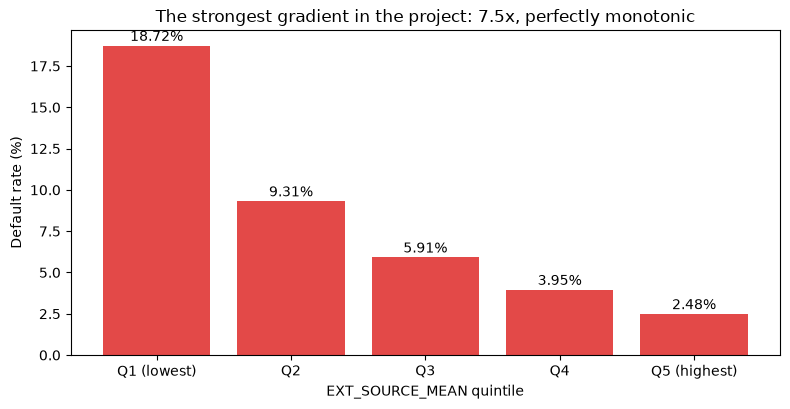

In [11]:
tmp = df.dropna(subset=['EXT_SOURCE_MEAN']).copy()
tmp['QUINTILE'] = pd.qcut(tmp['EXT_SOURCE_MEAN'], q=5,
                          labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])
result = tmp.groupby('QUINTILE', observed=True)['TARGET'].mean() * 100
print(result.round(2))

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(result.index.astype(str), result.values, color=C_RED)
for b, v in zip(bars, result.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, f"{v:.2f}%", ha='center', fontsize=10)
ax.set_ylabel('Default rate (%)')
ax.set_xlabel('EXT_SOURCE_MEAN quintile')
ax.set_title('The strongest gradient in the project: 7.5x, perfectly monotonic')
plt.tight_layout()
plt.savefig(FIG_PATH + "03_ext_source_mean_quintiles.png", dpi=150, bbox_inches='tight')
plt.show()

**Visual confirmation.** 18.72% → 2.48% across quintiles with zero reversals —
the cleanest single-feature separation found anywhere in the project.
`EXT_SOURCE_MEAN` becomes the headline feature (and is later confirmed #1 by
IV, the tree's root split, LR coefficients, and SHAP in notebooks 04–07).

# Batch 3 — Recency features (testing the winner's hypothesis)

The published winner's writeup claims **recent behaviour predicts better than
all-time behaviour**. The SQL pipeline only built all-time aggregates, so the
time-window versions are built here from the cleaned child tables — and the
claim gets tested three times on this project's own data, once per table.

In [12]:
# --- Bureau: overdue in the LAST 2 YEARS (DAYS_CREDIT > -730)
bureau_raw = pd.read_csv(DATA_PATH + "bureau_cleaned.csv")
recent_bureau = bureau_raw[bureau_raw['DAYS_CREDIT'] > -730]

recent_bureau_agg = recent_bureau.groupby('SK_ID_CURR').agg(
    RECENT_BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    RECENT_BUREAU_MAX_OVERDUE=('CREDIT_DAY_OVERDUE', 'max')
).reset_index()
print(f"Customers with bureau activity in the last 2 years: {recent_bureau_agg.shape[0]:,}")

df = df.drop(columns=['RECENT_BUREAU_LOAN_COUNT', 'RECENT_BUREAU_MAX_OVERDUE'], errors='ignore')
df = df.merge(recent_bureau_agg, on='SK_ID_CURR', how='left')
df[['RECENT_BUREAU_LOAN_COUNT', 'RECENT_BUREAU_MAX_OVERDUE']] = \
    df[['RECENT_BUREAU_LOAN_COUNT', 'RECENT_BUREAU_MAX_OVERDUE']].fillna(0)

df['HAS_RECENT_OVERDUE'] = (df['RECENT_BUREAU_MAX_OVERDUE'] > 0).astype(int)

print("\nRecent (last 2y) overdue flag:")
print(df.groupby('HAS_RECENT_OVERDUE')['TARGET'].mean())
print("\nAll-time overdue flag (from SQL pipeline, for comparison):")
print(df.groupby('HAS_OVERDUE_HISTORY')['TARGET'].mean())

del bureau_raw, recent_bureau

Customers with bureau activity in the last 2 years: 243,103

Recent (last 2y) overdue flag:
HAS_RECENT_OVERDUE
0   0.08
1   0.21
Name: TARGET, dtype: float64

All-time overdue flag (from SQL pipeline, for comparison):
HAS_OVERDUE_HISTORY
0   0.08
1   0.16
Name: TARGET, dtype: float64


**Test 1 — CONFIRMED, and it's the strongest rate in the project.**
`HAS_RECENT_OVERDUE`: 21.3% default vs 8.0% baseline (**2.7x**), beating the
all-time flag's 15.9% (2.0x). A customer overdue two months ago is a much
stronger signal than one overdue six years ago, even though both count as
"ever overdue". 21.3% is the highest default rate found for any single flag
in the entire project.

In [13]:
# --- Installments: late payment in the LAST 6 MONTHS (DAYS_INSTALMENT > -180)
installments_raw = pd.read_csv(DATA_PATH + "installments_cleaned.csv")
recent_installments = installments_raw[installments_raw['DAYS_INSTALMENT'] > -180]

recent_install_agg = recent_installments.groupby('SK_ID_CURR').agg(
    RECENT_LATE_PAYMENT_COUNT=('IS_PAST_DUE', 'sum'),
).reset_index()
recent_install_agg['HAS_RECENT_LATE_PAYMENT'] = \
    (recent_install_agg['RECENT_LATE_PAYMENT_COUNT'] > 0).astype(int)

df = df.drop(columns=['HAS_RECENT_LATE_PAYMENT'], errors='ignore')
df = df.merge(recent_install_agg[['SK_ID_CURR', 'HAS_RECENT_LATE_PAYMENT']],
              on='SK_ID_CURR', how='left')
df['HAS_RECENT_LATE_PAYMENT'] = df['HAS_RECENT_LATE_PAYMENT'].fillna(0).astype(int)

print("Recent (last 6m) late payment flag:")
print(df.groupby('HAS_RECENT_LATE_PAYMENT')['TARGET'].mean())
print("\nAll-time late payment flag (for comparison):")
print(df.groupby('HAS_LATE_PAYMENT')['TARGET'].mean())

del installments_raw, recent_installments

Recent (last 6m) late payment flag:
HAS_RECENT_LATE_PAYMENT
0   0.07
1   0.12
Name: TARGET, dtype: float64

All-time late payment flag (for comparison):
HAS_LATE_PAYMENT
0   0.07
1   0.09
Name: TARGET, dtype: float64


**Test 2 — CONFIRMED.** Recent lateness: 12.5% vs 7.4% (1.7x) beats the
all-time flag's 1.4x. Two tables in a row where recency wins — starting to
look like a general principle. One more test:

In [14]:
# --- Credit card: utilisation in the LAST 6 MONTHS (MONTHS_BALANCE > -6)
credit_card_raw = pd.read_csv(DATA_PATH + "credit_card_cleaned.csv")
recent_cc = credit_card_raw[credit_card_raw['MONTHS_BALANCE'] > -6]

recent_cc_agg = recent_cc.groupby('SK_ID_CURR').agg(
    RECENT_AVG_UTILIZATION=('UTILIZATION_RATIO', 'mean')
).reset_index()

df = df.drop(columns=['RECENT_AVG_UTILIZATION'], errors='ignore')
df = df.merge(recent_cc_agg, on='SK_ID_CURR', how='left')
print(f"Customers with recent card activity: {recent_cc_agg.shape[0]:,}")

del credit_card_raw, recent_cc

Customers with recent card activity: 103,556


In [22]:
# Compare recent vs all-time utilisation gradients (both computed HERE,
# self-contained — no cross-notebook variables)
recent_t = df.dropna(subset=['RECENT_AVG_UTILIZATION'])
recent_t = recent_t[recent_t['RECENT_AVG_UTILIZATION'] > 0].copy()
recent_t['BUCKET'] = pd.qcut(recent_t['RECENT_AVG_UTILIZATION'], q=5, duplicates='drop')
recent_rates = recent_t.groupby('BUCKET', observed=True)['TARGET'].mean() * 100

alltime_t = df[df['NUM_CC_RECORDS'] > 0].copy()
alltime_t['BUCKET'] = pd.cut(alltime_t['AVG_UTILIZATION'],
                             bins=[-0.01, 0.1, 0.3, 0.6, 0.9, 1.1],
                             labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
alltime_rates = alltime_t.groupby('BUCKET', observed=True)['TARGET'].mean() * 100

print("RECENT utilisation buckets:")
print(recent_rates.round(2))
print(f"  spread: {recent_rates.iloc[-1] / recent_rates.iloc[0]:.1f}x")
print("\nALL-TIME utilisation buckets:")
print(alltime_rates.round(2))
print(f"  spread: {alltime_rates.iloc[-1] / alltime_rates.iloc[0]:.1f}x")

RECENT utilisation buckets:
BUCKET
(-0.00099996, 0.282]    6.44
(0.282, 0.646]         10.06
(0.646, 0.881]         12.73
(0.881, 0.985]         14.71
(0.985, 1.069]         19.34
Name: TARGET, dtype: float64
  spread: 3.0x

ALL-TIME utilisation buckets:
BUCKET
Very Low     5.60
Low          6.94
Medium       8.86
High        13.04
Very High   19.25
Name: TARGET, dtype: float64
  spread: 3.4x


**Test 3 — REFUTED.** Recent utilisation (~3.0x spread) is *weaker* than
all-time utilisation (~3.6x). On reflection this makes sense: utilisation is a
continuous, ongoing **state**, not a discrete **event** — a longer observation
window gives a more stable, representative average. Same logic as MEAN beating
MAX for this exact column in EDA.

## The refined recency principle

> **Recency matters for discrete negative EVENTS** (overdue, missed payment) —
> a recent occurrence is a stronger signal than an old one.
> **Longer windows matter for continuous financial STATES** (utilisation,
> balance) — stability beats freshness.

This is the project's most valuable original finding: the winner's principle
was *partially* confirmed, and refined into something more precise. Both
utilisation versions still go to Stage 5; all-time stays the primary candidate.

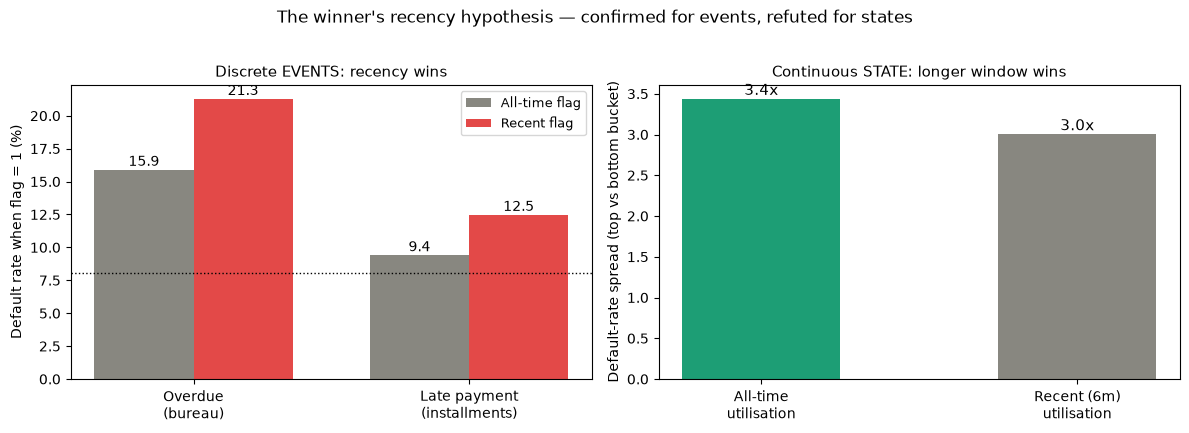

In [23]:
# The recency story in one picture
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Left: event flags — recency CONFIRMED
labels = ['Overdue\n(bureau)', 'Late payment\n(installments)']
alltime_vals = [df.groupby('HAS_OVERDUE_HISTORY')['TARGET'].mean()[1] * 100,
                df.groupby('HAS_LATE_PAYMENT')['TARGET'].mean()[1] * 100]
recent_vals  = [df.groupby('HAS_RECENT_OVERDUE')['TARGET'].mean()[1] * 100,
                df.groupby('HAS_RECENT_LATE_PAYMENT')['TARGET'].mean()[1] * 100]
x = np.arange(2)
axes[0].bar(x - 0.18, alltime_vals, width=0.36, color=C_GREY, label='All-time flag')
axes[0].bar(x + 0.18, recent_vals,  width=0.36, color=C_RED,  label='Recent flag')
for i in range(2):
    axes[0].text(i - 0.18, alltime_vals[i] + 0.3, f"{alltime_vals[i]:.1f}", ha='center', fontsize=10)
    axes[0].text(i + 0.18, recent_vals[i] + 0.3,  f"{recent_vals[i]:.1f}",  ha='center', fontsize=10)
axes[0].axhline(8.07, color='black', linestyle=':', linewidth=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Default rate when flag = 1 (%)')
axes[0].set_title('Discrete EVENTS: recency wins', fontsize=11)
axes[0].legend(fontsize=9)

# Right: continuous state — recency REFUTED
spreads = [alltime_rates.iloc[-1] / alltime_rates.iloc[0],
           recent_rates.iloc[-1] / recent_rates.iloc[0]]
bars = axes[1].bar(['All-time\nutilisation', 'Recent (6m)\nutilisation'], spreads,
                   color=[C_GREEN, C_GREY], width=0.5)
for b, v in zip(bars, spreads):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.1f}x", ha='center', fontsize=11)
axes[1].set_ylabel('Default-rate spread (top vs bottom bucket)')
axes[1].set_title('Continuous STATE: longer window wins', fontsize=11)

fig.suptitle("The winner's recency hypothesis — confirmed for events, refuted for states", y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + "03_recency_principle.png", dpi=150, bbox_inches='tight')
plt.show()

# Batch 4 — Standard community ratios

Three features used in almost every public solution for this competition.
Popularity is not evidence — each gets tested against this project's data.

In [24]:
df['CREDIT_INCOME_PERCENT']  = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_TERM']            = df['AMT_ANNUITY'] / df['AMT_CREDIT']

batch4 = ['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM']
print(df[batch4].describe())
print(f"\nMissing values (traces to AMT_ANNUITY's known 12 missing — documented in EDA):")
print(df[batch4].isnull().sum())

       CREDIT_INCOME_PERCENT  ANNUITY_INCOME_PERCENT  CREDIT_TERM
count              307511.00               307499.00    307499.00
mean                    3.96                    0.18         0.05
std                     2.69                    0.09         0.02
min                     0.00                    0.00         0.02
25%                     2.02                    0.11         0.04
50%                     3.27                    0.16         0.05
75%                     5.16                    0.23         0.06
max                    84.74                    1.88         0.12

Missing values (traces to AMT_ANNUITY's known 12 missing — documented in EDA):
CREDIT_INCOME_PERCENT      0
ANNUITY_INCOME_PERCENT    12
CREDIT_TERM               12
dtype: int64


In [25]:
correlations = df[batch4 + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()
print(correlations)

CREDIT_INCOME_PERCENT    -0.01
CREDIT_TERM               0.01
ANNUITY_INCOME_PERCENT    0.01
Name: TARGET, dtype: float64


**Honest negative result.** All three show near-zero correlation
(−0.008 to +0.014) — far weaker than their reputation in public solutions
suggests. They are carried into Stage 5 anyway (correlation can miss
non-linear value that trees exploit — and indeed `CREDIT_TERM` is later
vindicated there with IV 0.115 and a top-5 SHAP rank), but the lesson is
recorded: **community-famous features do not automatically transfer**; test
everything on your own data.

# Consolidation — inventory, audit, save

In [26]:
new_features_all = [
    'CREDIT_ANNUITY_RATIO', 'CREDIT_GOODS_PRICE_RATIO', 'CREDIT_DOWNPAYMENT',
    'AGE_INT', 'DEBT_CREDIT_RATIO',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_SUM', 'EXT_SOURCE_STD', 'ANNUITY_TO_AVG_INSTALMENT',
    'RECENT_BUREAU_LOAN_COUNT', 'RECENT_BUREAU_MAX_OVERDUE', 'HAS_RECENT_OVERDUE',
    'HAS_RECENT_LATE_PAYMENT', 'RECENT_AVG_UTILIZATION',
    'CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM',
]

# Final integrity audit: no infinities may survive into the checkpoint
inf_counts = {c: int(np.isinf(df[c]).sum()) for c in new_features_all}
bad = {c: n for c, n in inf_counts.items() if n > 0}
assert not bad, f"Infinite values found: {bad}"
print(f"Integrity check: 0 infinite values across all {len(new_features_all)} new features.")

Integrity check: 0 infinite values across all 17 new features.


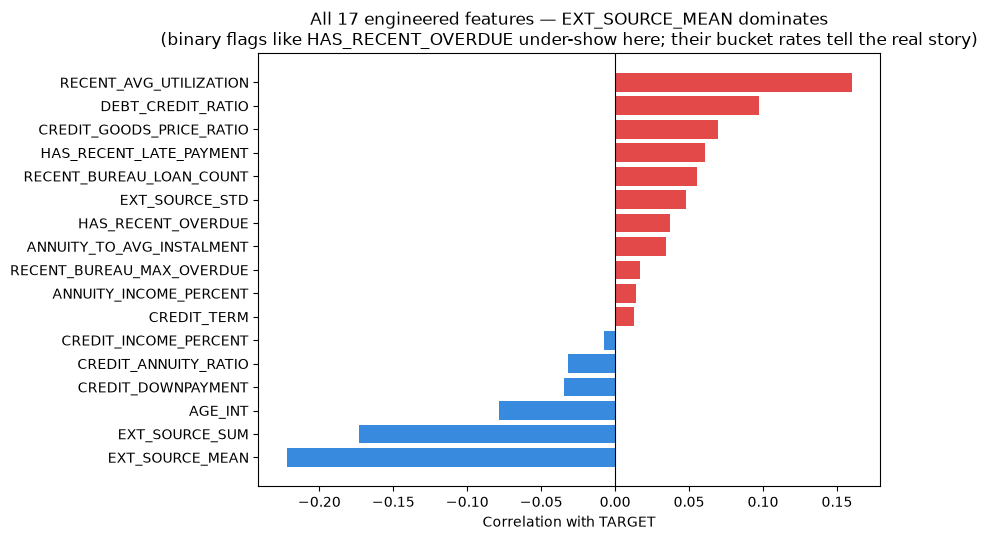

In [27]:
# Every engineered feature's linear signal, in one picture
corr_all = df[new_features_all + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = [C_BLUE if v < 0 else C_RED for v in corr_all.values]
bars = ax.barh(corr_all.index, corr_all.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with TARGET')
ax.set_title('All 17 engineered features — EXT_SOURCE_MEAN dominates\n'
             '(binary flags like HAS_RECENT_OVERDUE under-show here; their bucket rates tell the real story)')
plt.tight_layout()
plt.savefig(FIG_PATH + "03_all_features_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

## Feature inventory — what was built and what the evidence says

| # | Feature | Batch | Evidence | Verdict |
|---|---|---|---|---|
| 1 | `EXT_SOURCE_MEAN` | 2 | corr −0.222; 18.7%→2.5% quintiles (7.5x, monotonic) | **Star feature** |
| 2 | `HAS_RECENT_OVERDUE` | 3 | 21.3% vs 8.0% (2.7x) — highest single rate in project | **Strong** |
| 3 | `EXT_SOURCE_SUM` | 2 | corr −0.173 (near-duplicate of MEAN) | Strong; Stage 5 arbitrates |
| 4 | `DEBT_CREDIT_RATIO` | 1 | corr +0.097; 5.7%→12.3% (2.2x) | **Keep** |
| 5 | `HAS_RECENT_LATE_PAYMENT` | 3 | 12.5% vs 7.4% (1.7x) beats all-time 1.4x | **Keep** |
| 6 | `AGE_INT` | 1 | corr −0.078, matches EDA age pattern | Keep |
| 7 | `CREDIT_GOODS_PRICE_RATIO` | 1 | corr +0.069 | Keep |
| 8 | `CREDIT_DOWNPAYMENT` | 1 | monotonic 5.0%→9.8% bucket gradient | Keep (bucket test saved it) |
| 9 | `RECENT_AVG_UTILIZATION` | 3 | 3.0x spread — weaker than all-time (3.6x) | Keep; all-time preferred |
| 10 | `EXT_SOURCE_STD` | 2 | weak + corr: bureau disagreement = mild risk | Keep, low priority |
| 11 | `ANNUITY_TO_AVG_INSTALMENT` | 2 | weak after winsorising a 4,101x outlier | Stage 5 decides |
| 12 | `RECENT_BUREAU_LOAN_COUNT` | 3 | supporting recency context | Stage 5 decides |
| 13 | `RECENT_BUREAU_MAX_OVERDUE` | 3 | severity companion to the recent flag | Stage 5 decides |
| 14 | `CREDIT_ANNUITY_RATIO` | 1 | non-monotonic buckets | Lower priority |
| 15 | `CREDIT_TERM` | 4 | corr +0.013 — but later vindicated by IV/SHAP | Stage 5 decides |
| 16 | `ANNUITY_INCOME_PERCENT` | 4 | corr +0.014 (community favourite, failed here) | Honest negative |
| 17 | `CREDIT_INCOME_PERCENT` | 4 | corr −0.008 (community favourite, failed here) | Honest negative |

In [28]:
assert df.shape == (307511, 98), f"Unexpected final shape: {df.shape}"

df.to_csv(DATA_PATH + "model_ready_features.csv", index=False)
print(f"Saved: model_ready_features.csv  {df.shape}")
print(f"(81 input columns + {len(new_features_all)} engineered features)")

Saved: model_ready_features.csv  (307511, 98)
(81 input columns + 17 engineered features)


---
# Summary

Seventeen features built in four batches, every one tested before keeping.
The two headline results: **`EXT_SOURCE_MEAN`** (strongest feature in the
project, 7.5x monotonic spread) and the **refined recency principle**
(events reward recency, states reward longer windows) — a hypothesis from the
competition winner that this project partially confirmed and partially
refuted with its own evidence. Three popular community ratios failed honestly
and were documented as negatives rather than assumed useful.

## Next: Notebook 04 — feature selection
Layered filtering of all 98 columns: Information Value → correlation →
Mutual Information cross-check → VIF, producing the 45-column general set and
the 41-column VIF-reduced Logistic Regression set.